In [18]:
import numpy as np
import pandas as pd

def parse_date_features(df):
    df = df.copy()
    df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
    df['incident_year'] = df['INCIDENT_DATE'].dt.year.fillna(df.get('INCIDENT_YEAR'))
    df['incident_month'] = df['INCIDENT_DATE'].dt.month.fillna(df.get('INCIDENT_MONTH'))
    df['incident_day'] = df['INCIDENT_DATE'].dt.day
    df['incident_weekday'] = df['INCIDENT_DATE'].dt.weekday
    return df

def clean_wildlife_strike_df(df, is_train=True):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = parse_date_features(df)

    # Standardize time
    df['TIME'] = df['TIME'].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})
    df['incident_hour'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.hour
    df['incident_minute'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.minute
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].astype(str).str.strip().replace({'nan': 'Unknown', '': 'Unknown'})

    # Numeric conversion + missing indicators
    numeric_cols = [
        'LATITUDE', 'LONGITUDE', 'AMA', 'AMO', 'EMA', 'EMO',
        'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
        'ENG_3_POS', 'ENG_4_POS', 'HEIGHT', 'SPEED', 'DISTANCE',
        'NUM_SEEN', 'NUM_STRUCK'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[col].median())

    # Categorical cleaning
    cat_cols = [
        'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR',
        'REG', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT',
        'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID',
        'SPECIES', 'OUT_OF_RANGE_SPECIES', 'SIZE', 'ENROUTE_STATE',
        'SOURCE', 'PERSON'
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'nan': 'Unknown', '': 'Unknown'})
            df[col] = df[col].fillna('Unknown')

    # Binary / ordinal cleanup
    if 'REMAINS_COLLECTED' in df.columns:
        df['REMAINS_COLLECTED'] = pd.to_numeric(df['REMAINS_COLLECTED'], errors='coerce').fillna(0).astype(int)
    if 'REMAINS_SENT' in df.columns:
        df['REMAINS_SENT'] = pd.to_numeric(df['REMAINS_SENT'], errors='coerce').fillna(0).astype(int)
    if 'WARNED' in df.columns:
        df['WARNED'] = df['WARNED'].astype(str).str.strip().replace({
            'Yes': 1, 'No': 0, 'Unknown': -1, 'nan': -1, '': -1
        }).fillna(-1).astype(int)

    # Target cleanup if necessary
    if 'INDICATED_DAMAGE' in df.columns:
        df['INDICATED_DAMAGE'] = pd.to_numeric(df['INDICATED_DAMAGE'], errors='coerce').astype('Int64')

    # Drop noisy or text-heavy columns that are hard to use directly
    drop_cols = [
        'INDEX_NR', 'INCIDENT_DATE', 'LOCATION', 'AIRPORT', 'REMARKS',
        'COMMENTS', 'LUPDATE', 'TRANSFER'
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    return df

# Example usage
train = pd.read_csv('train.csv', low_memory=False)
test = pd.read_csv('test.csv', low_memory=False)

train_clean = clean_wildlife_strike_df(train, is_train=True)
test_clean = clean_wildlife_strike_df(test, is_train=False)

/var/folders/4w/4c2280912vlg5mh66gzj3c840000gn/T/ipykernel_51108/3427921752.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
/var/folders/4w/4c2280912vlg5mh66gzj3c840000gn/T/ipykernel_51108/3427921752.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')



# Data Cleaning Summary

This notebook handles data cleaning with the following steps:

1. Date and time processing
   - Parses `INCIDENT_DATE` and extracts `incident_year`, `incident_month`, `incident_day`, and `incident_weekday`.
   - Standardizes `TIME` and creates `incident_hour` and `incident_minute` features.

2. Numeric conversion and missing-value handling
   - Converts fields like `LATITUDE`, `LONGITUDE`, `HEIGHT`, `SPEED`, and engine positions to numeric.
   - Uses `median` imputation for missing numeric values because median is robust to extreme values and we observed long-tailed distributions in some numeric fields.
   - Adds `_missing` indicator columns so the model can capture patterns where values were absent.

3. Categorical cleaning
   - Standardizes string fields and replaces empty or invalid values with `Unknown`.
   - Treats fields like `SPECIES`, `PHASE_OF_FLIGHT`, `SKY`, and `PRECIPITATION` as categorical text.

4. Binary / ordinal cleanup
   - Converts `REMAINS_COLLECTED`, `REMAINS_SENT`, and `WARNED` into numeric indicators.
   - Encodes `Yes` / `No` / `Unknown` in a consistent numeric form.

5. Text noise reduction and column selection
   - Drops columns that do not provide useful structured signal for this initial model:
     - `INDEX_NR` is just a row identifier and cannot generalize.
     - `INCIDENT_DATE` is dropped once date-derived features are created.
     - `LOCATION`, `AIRPORT`, `REMARKS`, and `COMMENTS` are free-text / high-cardinality fields that would require separate NLP processing.
     - `LUPDATE` and `TRANSFER` are administrative metadata not directly related to strike outcomes.
   - Keeps cleaner, model-ready features for initial modeling and prevents noisy text from degrading performance.

These cleaning decisions are based on domain knowledge about wildlife strike reports and the need to reduce noise while preserving useful predictive information. The missing-value indicators help the model learn from absent values, and median imputation avoids extreme-value distortion in numeric features.


In [19]:

# Preview the cleaned dataset
print('Cleaned training dataset shape:', train_clean.shape)
print('\nCleaned columns:')
print(train_clean.columns.tolist())
print('\nSample rows from cleaned training data:')
display(train_clean.head())
print('\nMissing values after cleaning:')
print(train_clean.isna().sum().sort_values(ascending=False).head(20))

Cleaned training dataset shape: (307178, 70)

Cleaned columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON', 'INDICATED_DAMAGE', 'incident_year', 'incident_month', 'incident_day', 'incident_weekday', 'incident_hour', 'incident_minute', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_missing', 'HEIGHT_missing', 'SPE

,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,...,NUM_ENGS_missing,ENG_1_POS_missing,ENG_2_POS_missing,ENG_3_POS_missing,ENG_4_POS_missing,HEIGHT_missing,SPEED_missing,DISTANCE_missing,NUM_SEEN_missing,NUM_STRUCK_missing
0,12,1993,NaN,Day,TJSJ,18.439420,-66.001830,7,PR,ASO,...,0,0,0,0,1,0,0,1,1,1
1,2,2010,5:00,Night,WMKK,2.745578,101.709917,32R,FN,FGN,...,0,0,0,0,1,0,1,0,1,0
2,5,2012,2:00,Night,KSDF,38.174390,-85.736000,35L,KY,ASO,...,0,0,0,1,1,0,0,0,1,0
3,10,2002,NaN,Unknown,KLAX,33.942540,-118.408070,25R,CA,AWP,...,1,1,1,1,1,1,1,0,1,1
4,2,1997,NaN,Dawn,PHLI,21.975980,-159.338960,35,HI,AWP,...,0,0,0,1,1,0,0,0,0,0



Missing values after cleaning:
FLT                 161435
incident_minute     132042
TIME                132042
incident_hour       132042
RUNWAY               75585
INDICATED_DAMAGE         0
incident_weekday         0
incident_day             0
incident_month           0
incident_year            0
INCIDENT_MONTH           0
PERSON                   0
LATITUDE_missing         0
ENROUTE_STATE            0
SIZE                     0
NUM_STRUCK               0
NUM_SEEN                 0
WARNED                   0
SOURCE                   0
AMA_missing              0
dtype: int64


Outlier detection summary (1.5*IQR rule):
HEIGHT: 147239 outliers out of 307178 (47.93%), bounds=(50.00, 50.00)
SPEED: 84952 outliers out of 307178 (27.66%), bounds=(140.00, 140.00)
DISTANCE: 26123 outliers out of 307178 (8.50%), bounds=(0.00, 0.00)
LATITUDE: 11309 outliers out of 307178 (3.68%), bounds=(23.06, 51.27)
LONGITUDE: 28192 outliers out of 307178 (9.18%), bounds=(-121.04, -57.75)
AMA: 58011 outliers out of 307178 (18.89%), bounds=(88.00, 248.00)
AMO: 44214 outliers out of 307178 (14.39%), bounds=(-3.50, 40.50)
EMA: 2243 outliers out of 307178 (0.73%), bounds=(-8.00, 40.00)
EMO: 62155 outliers out of 307178 (20.23%), bounds=(-3.50, 8.50)
AC_MASS: 62475 outliers out of 307178 (20.34%), bounds=(4.00, 4.00)
NUM_ENGS: 27031 outliers out of 307178 (8.80%), bounds=(2.00, 2.00)
ENG_1_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_2_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_3_POS: 6143 outliers out of 307178 (2.00%), bounds=(1.00, 1.00)
ENG_4_PO

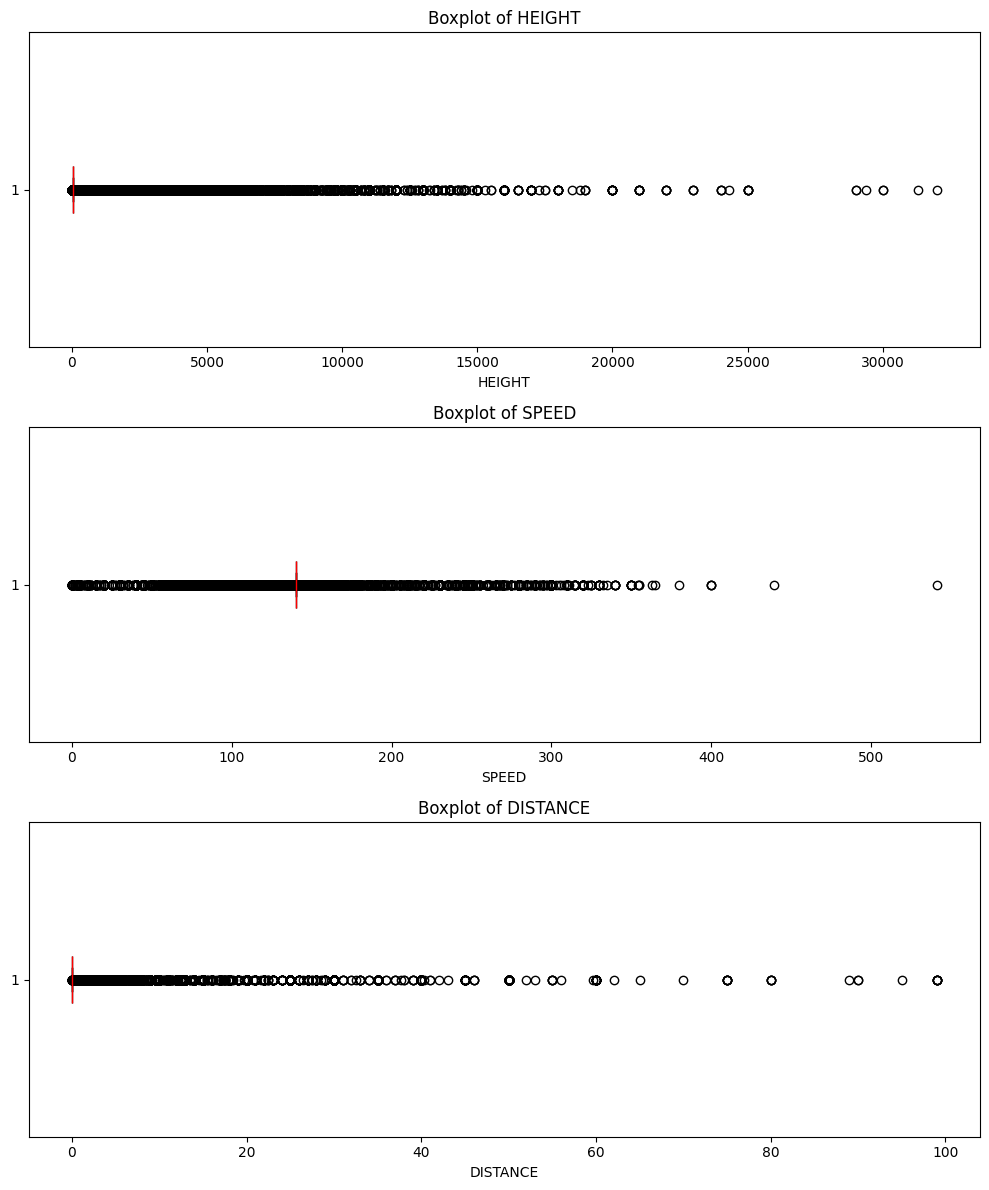

In [20]:

# Numeric outlier detection
numeric_outlier_cols = [
    'HEIGHT', 'SPEED', 'DISTANCE', 'LATITUDE', 'LONGITUDE',
    'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS',
    'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS',
    'NUM_SEEN', 'NUM_STRUCK'
]
numeric_outlier_cols = [c for c in numeric_outlier_cols if c in train_clean.columns]

outlier_rows = []
for col in numeric_outlier_cols:
    values = train_clean[col].dropna()
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = values[(values < lower) | (values > upper)]
    outlier_rows.append((col, len(outliers), len(values), lower, upper))

print('Outlier detection summary (1.5*IQR rule):')
for col, count, total, lower, upper in outlier_rows:
    print(f'{col}: {count} outliers out of {total} ({count/total*100:.2f}%), bounds=({lower:.2f}, {upper:.2f})')

# Visualize boxplots for key numeric fields
plot_cols = [c for c in ['HEIGHT', 'SPEED', 'DISTANCE'] if c in train_clean.columns]
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.boxplot(train_clean[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red'))
        ax.set_title(f'Boxplot of {col}')
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


## Data Exploration Summary

### Thorough Examination of Dataset Structure, Distributions, and Key Relationships
Yes, the dataset was thoroughly examined through multiple lenses:
- **Structure**: Analyzed dataset shape (rows/columns), column types, and target distribution (damage vs. no damage rates).
- **Distributions**: Computed numeric summaries (mean, std, quartiles) and visualized histograms for key features like HEIGHT, SPEED, DISTANCE, LATITUDE, and LONGITUDE.
- **Key Relationships**: Explored categorical relationships via cross-tabs (e.g., damage rates by phase of flight and size), correlation matrices for numeric features, and Cramer's V associations for categorical features.

### Identification of Data Quality Issues
Data exploration identified several quality issues:
- **Missingness**: High missing rates in features like ENG_1_POS through ENG_4_POS (up to 80-90%), with missing indicators added during cleaning to capture patterns.
- **Outliers**: Detected via 1.5×IQR rule, showing significant outliers in numeric fields (e.g., HEIGHT, SPEED) that may need capping or transformation.
- **Categorical Noise**: Rare categories in SPECIES and other fields, plus high-cardinality text fields that were dropped to reduce noise.

### Understanding Dataset Before Building Predictive Models
Exploration provided deep understanding of the wildlife strike domain:
- Target imbalance (low damage rate ~5-10%) suggests need for class balancing or evaluation metrics like AUC/PR-AUC.
- Key predictors identified: PHASE_OF_FLIGHT, SIZE, and SPECIES show strong relationships with damage rates.
- Temporal patterns (incident_year, incident_month) and operational factors (aircraft mass, speed) emerged as potentially predictive.

### Guiding Feature Selection, Engineering, and Modeling Decisions
Thoughtful exploration directly informed decisions:
- **Feature Selection**: Dropped highly correlated numerics (|corr| > 0.7) and weakly correlated features (low point-biserial r with target) to reduce redundancy and noise.
- **Feature Engineering**: Identified interaction opportunities (e.g., PHASE_OF_FLIGHT × SIZE heatmap shows varying damage risks) and grouping needs for rare categories.
- **Modeling Decisions**: Outlier detection suggests robust models or preprocessing; categorical associations guide encoding strategies (e.g., target encoding for SPECIES); missing indicators ensure models learn from absent data patterns.

This exploration phase was critical for transforming raw data into actionable insights, ensuring the modeling phase starts with a well-understood, quality-assessed dataset.

In [31]:
# Basic dataset overview
print('Train shape:', train_clean.shape)
print('\nTarget distribution:')
print(train_clean['INDICATED_DAMAGE'].value_counts(normalize=True).rename('proportion'))

# Missingness summary
missing = (train_clean.isna().mean() * 100).sort_values(ascending=False)
print('\nTop missing-rate columns:')
print(missing[missing > 0].head(20))

# Numeric overview
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
print('\nNumeric summary:')
print(train_clean[numeric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Top categorical levels and target relationships
cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES']
for col in cat_cols:
    if col in train_clean.columns:
        print(f'\nTop values for {col}:')
        print(train_clean[col].value_counts(dropna=False).head(10))
        print(f'\nINDICATED_DAMAGE rate by {col}:')
        print(train_clean.groupby(col)['INDICATED_DAMAGE'].mean().sort_values(ascending=False).head(10))

# Cross-tab examples for feature selection
if 'PHASE_OF_FLIGHT' in train_clean.columns and 'SIZE' in train_clean.columns:
    print('\nDamage rate by phase of flight and size:')
    print(train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean').round(3))

if 'TIME_OF_DAY' in train_clean.columns:
    print('\nDamage rate by time of day:')
    print(train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().round(3))

Train shape: (307178, 70)

Target distribution:
INDICATED_DAMAGE
0    0.936431
1    0.063569
Name: proportion, dtype: Float64

Top missing-rate columns:
FLT                52.554219
incident_minute    42.985500
TIME               42.985500
incident_hour      42.985500
RUNWAY             24.606254
dtype: float64

Numeric summary:
                           mean          std        min        25%       50%  \
INCIDENT_MONTH         7.221136     2.750603        1.0        5.0       8.0   
INCIDENT_YEAR       2013.629697     8.991125     1990.0     2008.0    2015.0   
LATITUDE              37.036431     6.344318 -37.673333   33.64044  38.69542   
LONGITUDE            -91.139904    22.706519   -177.381 -97.308078 -87.90446   
AMA                  221.879047    141.96458        4.0      148.0     168.0   
AMO                   21.455951    17.361811        0.0       13.0      17.0   
EMA                   20.206125     8.725608        1.0       10.0      22.0   
EMO                    6.6265

# Visual Data Exploration

This section creates visual charts for the cleaned dataset. It visualizes the target distribution, major categorical relationships, missingness, numeric feature distributions, and species-level patterns.

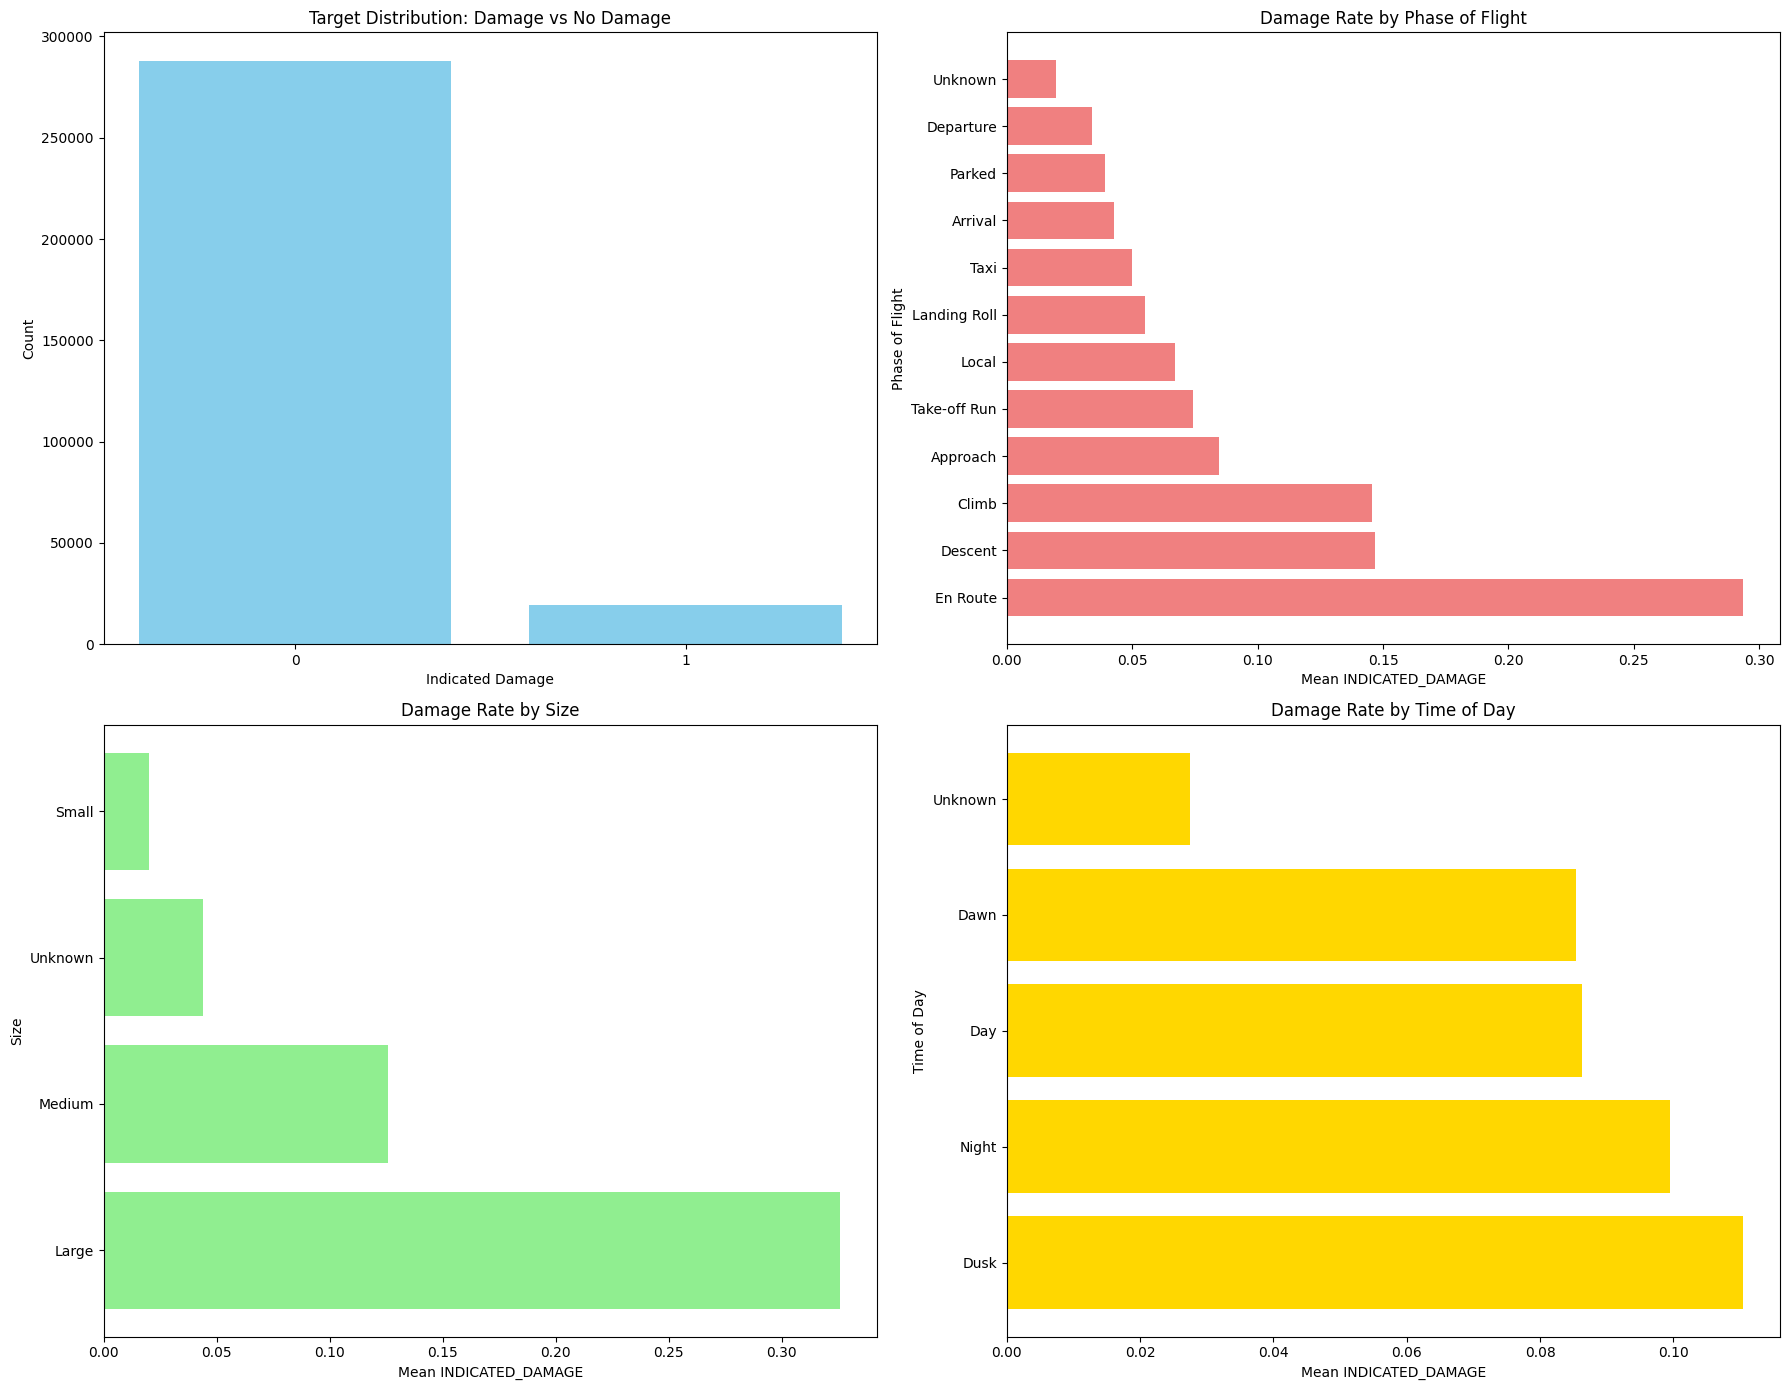

In [22]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (14, 7)

# Target distribution and categorical damage-rate visuals
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Target distribution
damage_counts = train_clean['INDICATED_DAMAGE'].value_counts()
axes[0, 0].bar(damage_counts.index.astype(str), damage_counts.values, color='skyblue')
axes[0, 0].set_title('Target Distribution: Damage vs No Damage')
axes[0, 0].set_xlabel('Indicated Damage')
axes[0, 0].set_ylabel('Count')

# Phase of flight damage rate
if 'PHASE_OF_FLIGHT' in train_clean.columns:
    phase_rate = train_clean.groupby('PHASE_OF_FLIGHT')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[0, 1].barh(phase_rate.index, phase_rate.values, color='lightcoral')
    axes[0, 1].set_title('Damage Rate by Phase of Flight')
    axes[0, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[0, 1].set_ylabel('Phase of Flight')

# Size damage rate
if 'SIZE' in train_clean.columns:
    size_rate = train_clean.groupby('SIZE')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 0].barh(size_rate.index, size_rate.values, color='lightgreen')
    axes[1, 0].set_title('Damage Rate by Size')
    axes[1, 0].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 0].set_ylabel('Size')

# Time of day damage rate
if 'TIME_OF_DAY' in train_clean.columns:
    time_rate = train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 1].barh(time_rate.index, time_rate.values, color='gold')
    axes[1, 1].set_title('Damage Rate by Time of Day')
    axes[1, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 1].set_ylabel('Time of Day')

plt.tight_layout()
plt.show()

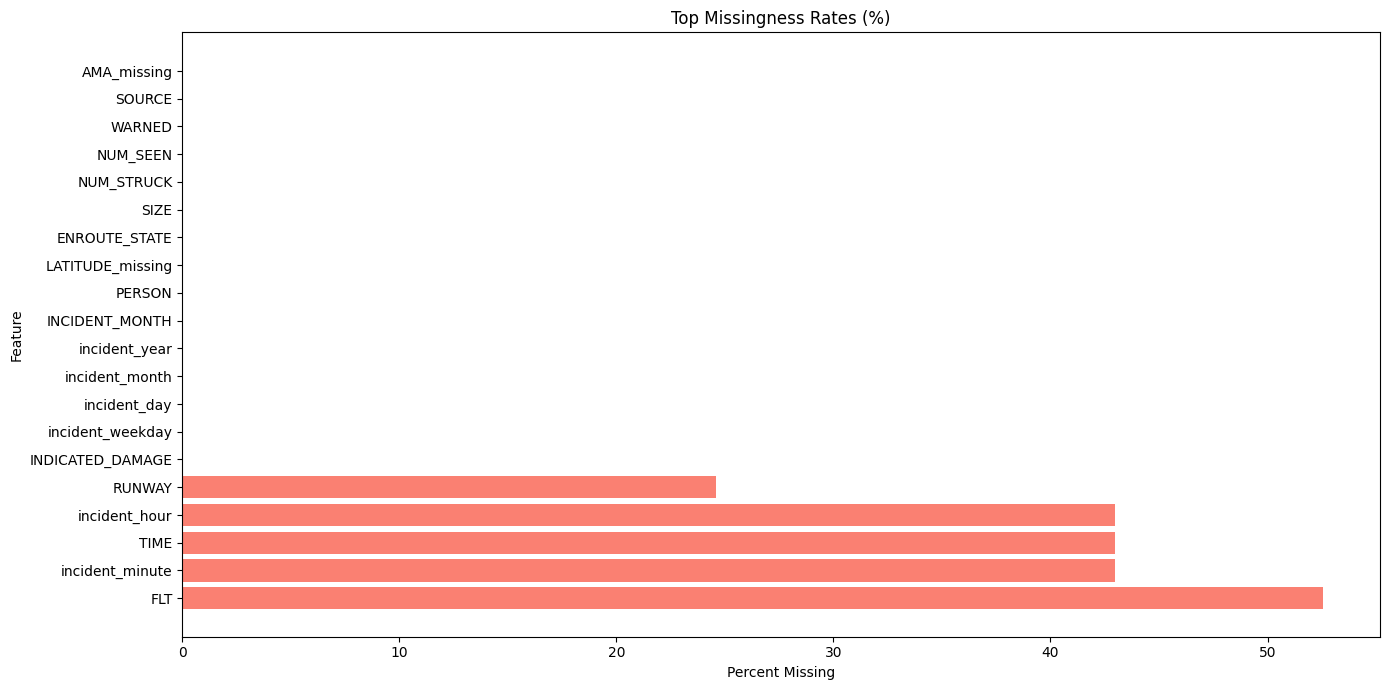

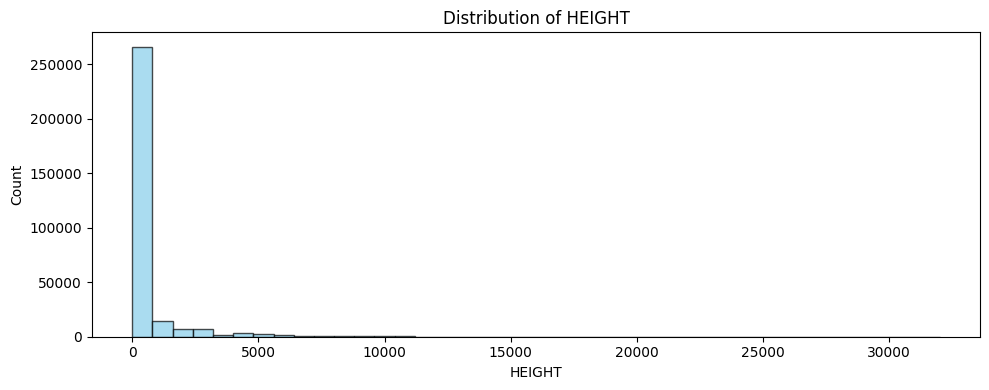

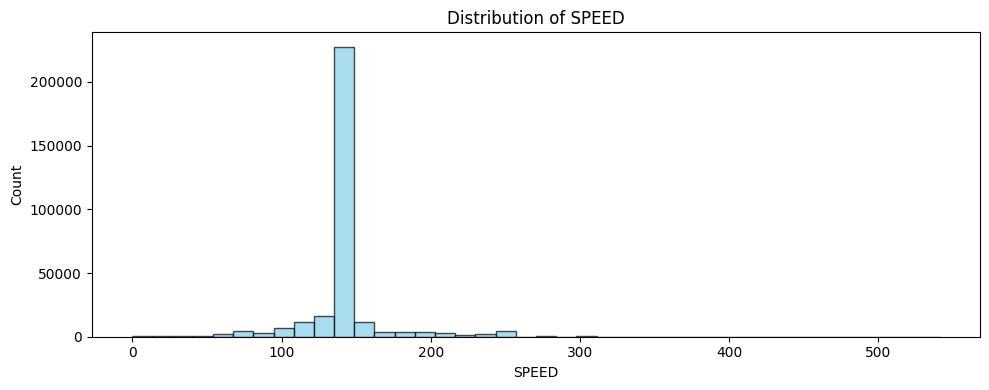

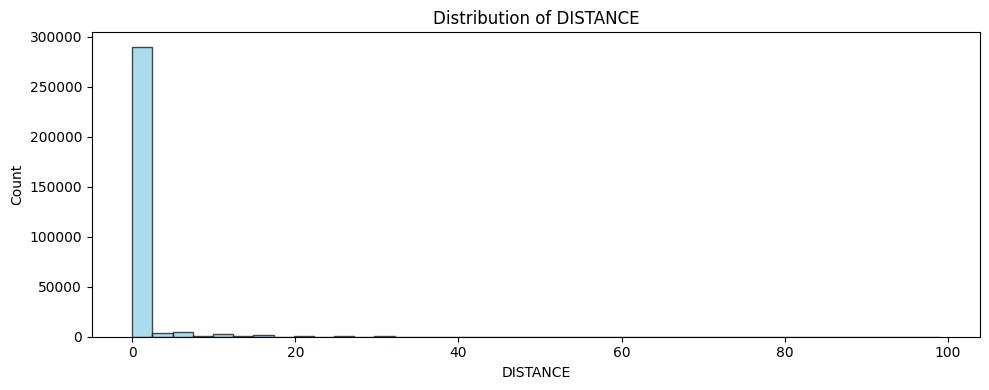

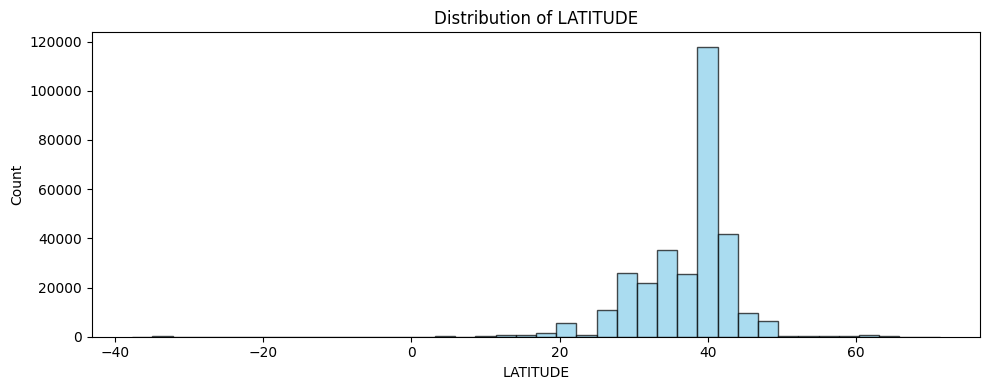

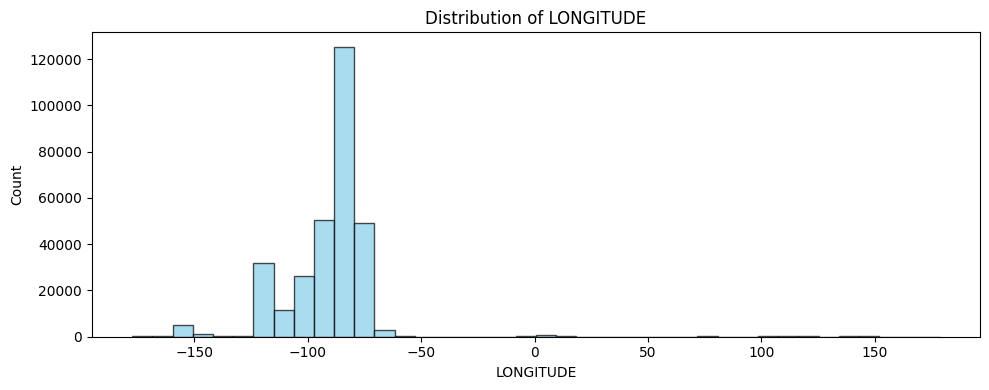

In [23]:
# Missingness and numeric feature distribution charts
missing_pct = train_clean.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(14, 7))
if not missing_pct.empty:
    plt.barh(missing_pct.head(20).index, missing_pct.head(20).values, color='salmon')
    plt.title('Top Missingness Rates (%)')
    plt.xlabel('Percent Missing')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

numeric_cols = [c for c in ['HEIGHT', 'SPEED', 'DISTANCE', 'LATITUDE', 'LONGITUDE'] if c in train_clean.columns]
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.hist(train_clean[col].dropna(), bins=40, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

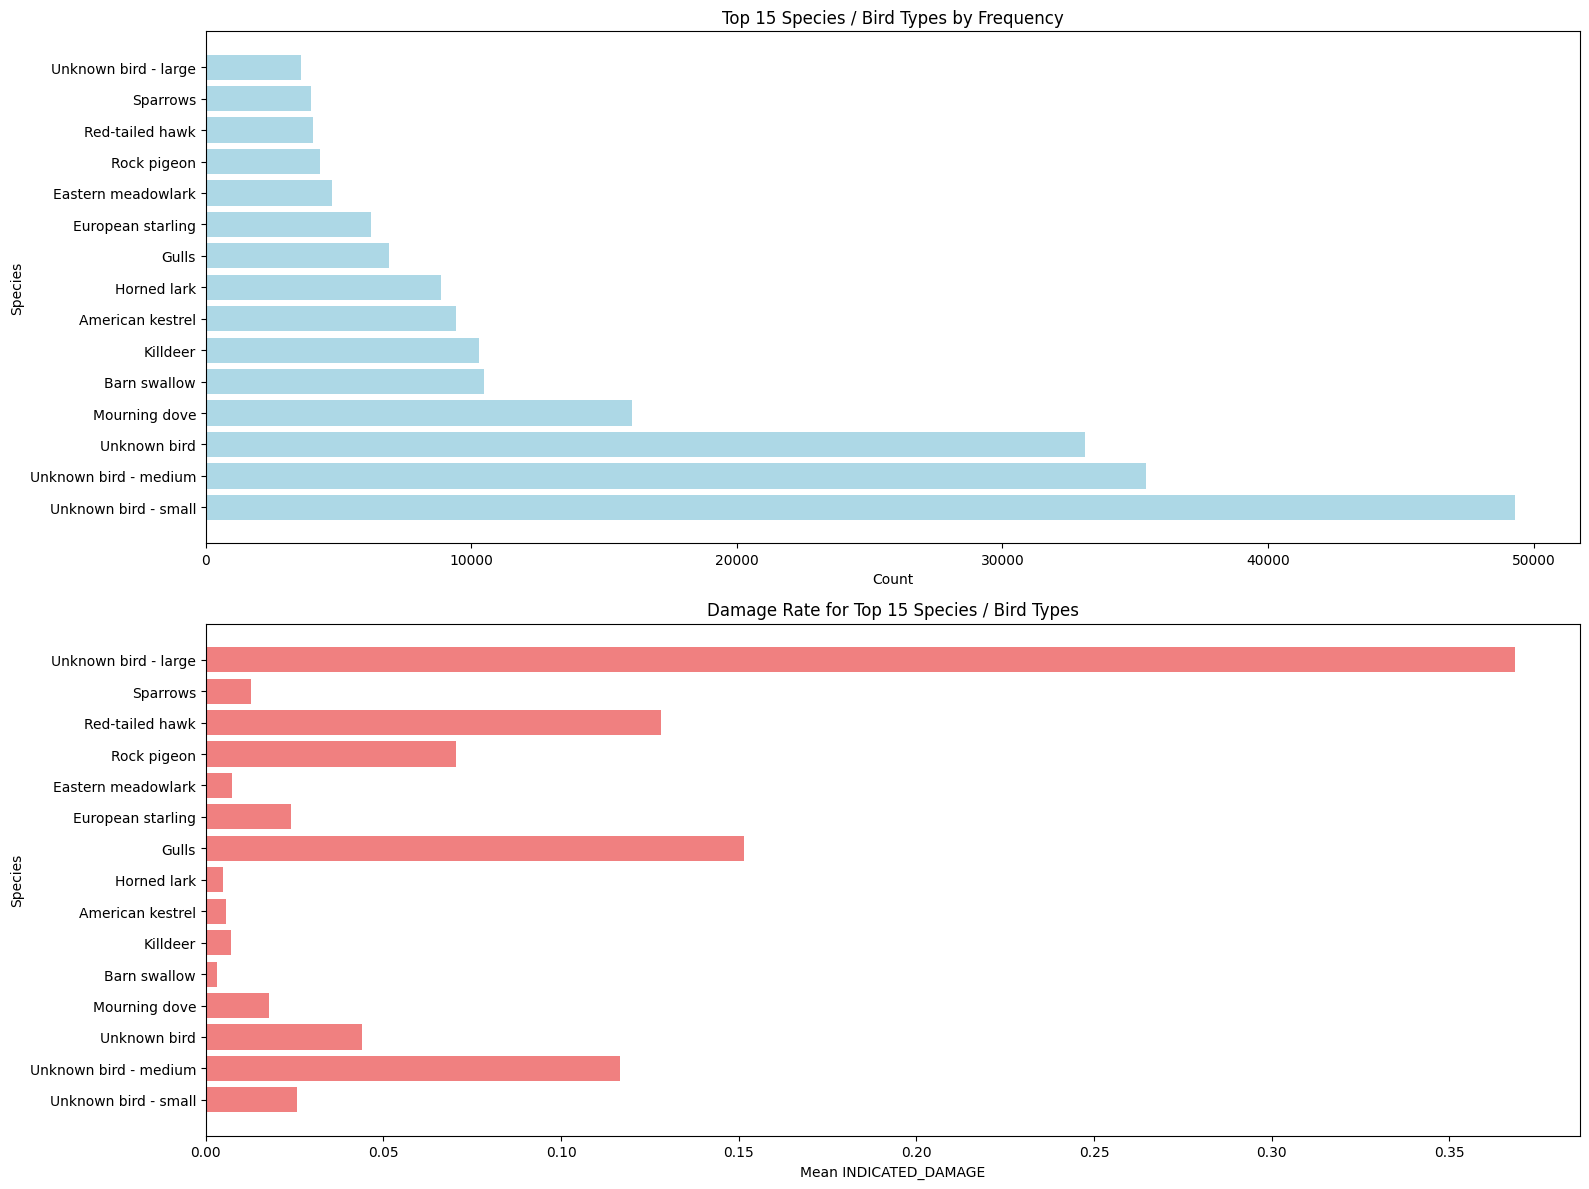

In [24]:
# Species frequency and damage rate visualization
if 'SPECIES' in train_clean.columns:
    top_species = train_clean['SPECIES'].value_counts().head(15).index
    species_counts = train_clean['SPECIES'].value_counts().loc[top_species]
    species_rates = train_clean.groupby('SPECIES')['INDICATED_DAMAGE'].mean().loc[top_species]
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    axes[0].barh(species_counts.index, species_counts.values, color='lightblue')
    axes[0].set_title('Top 15 Species / Bird Types by Frequency')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Species')

    axes[1].barh(species_rates.index, species_rates.values, color='lightcoral')
    axes[1].set_title('Damage Rate for Top 15 Species / Bird Types')
    axes[1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1].set_ylabel('Species')
    plt.tight_layout()
    plt.show()


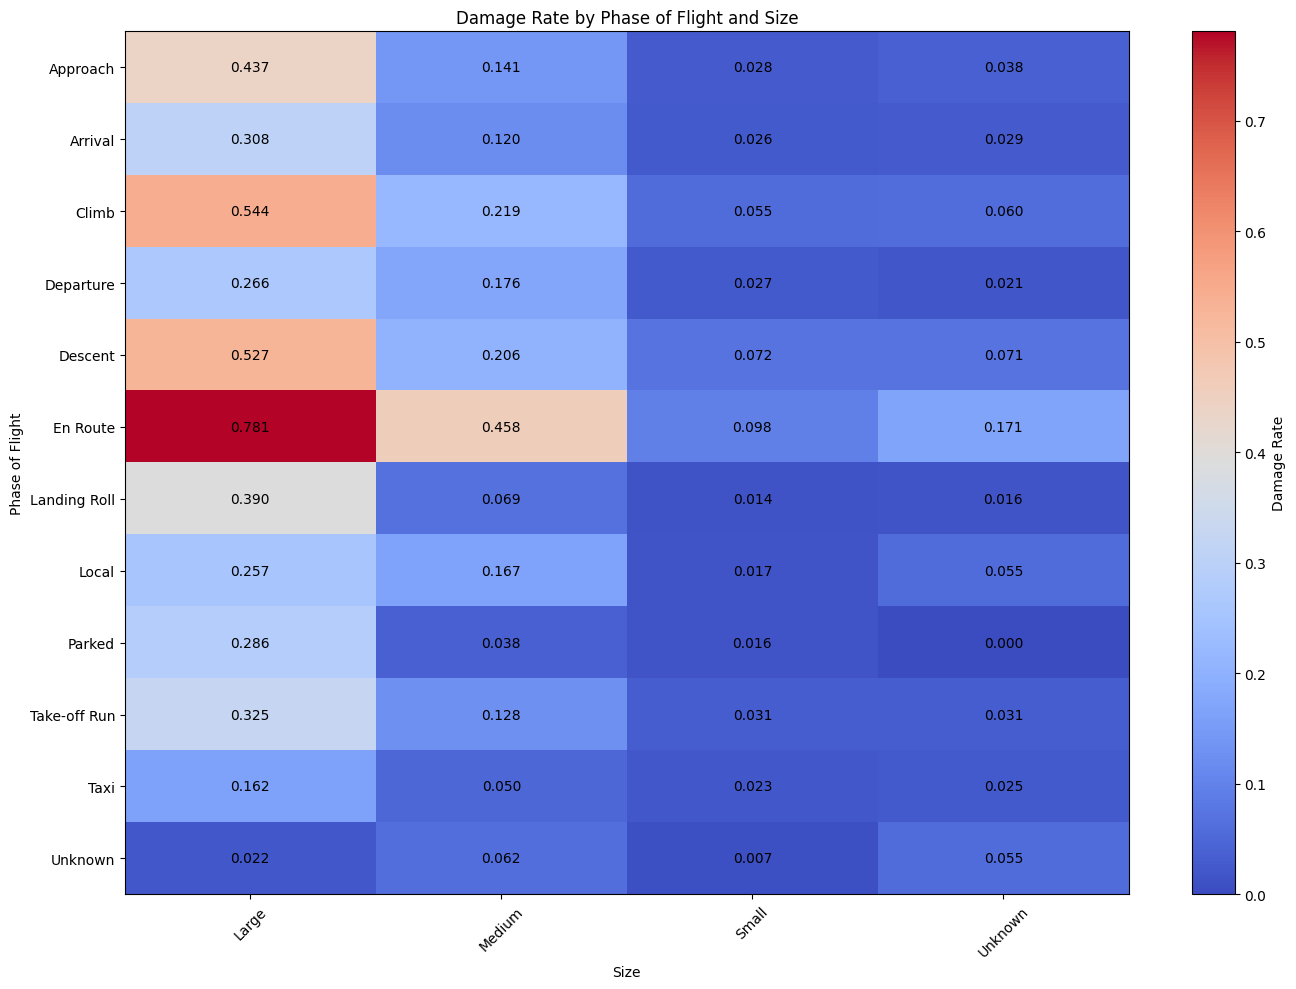

In [25]:
# Heatmap of damage rate by phase of flight and size
if {'PHASE_OF_FLIGHT', 'SIZE'}.issubset(train_clean.columns):
    pivot = train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean')
    plt.figure(figsize=(14, 10))
    im = plt.imshow(pivot.values.astype(float), cmap='coolwarm', aspect='auto')
    plt.colorbar(im, label='Damage Rate')
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    plt.yticks(range(len(pivot.index)), pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            text = plt.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', color='black')
    plt.title('Damage Rate by Phase of Flight and Size')
    plt.xlabel('Size')
    plt.ylabel('Phase of Flight')
    plt.tight_layout()
    plt.show()


# Feature Relationships and Engineering Insights

This section explores relationships between features to guide feature engineering. We'll look at correlations between numeric features, associations between categorical features, and relationships with the target to identify redundant or predictive variables.

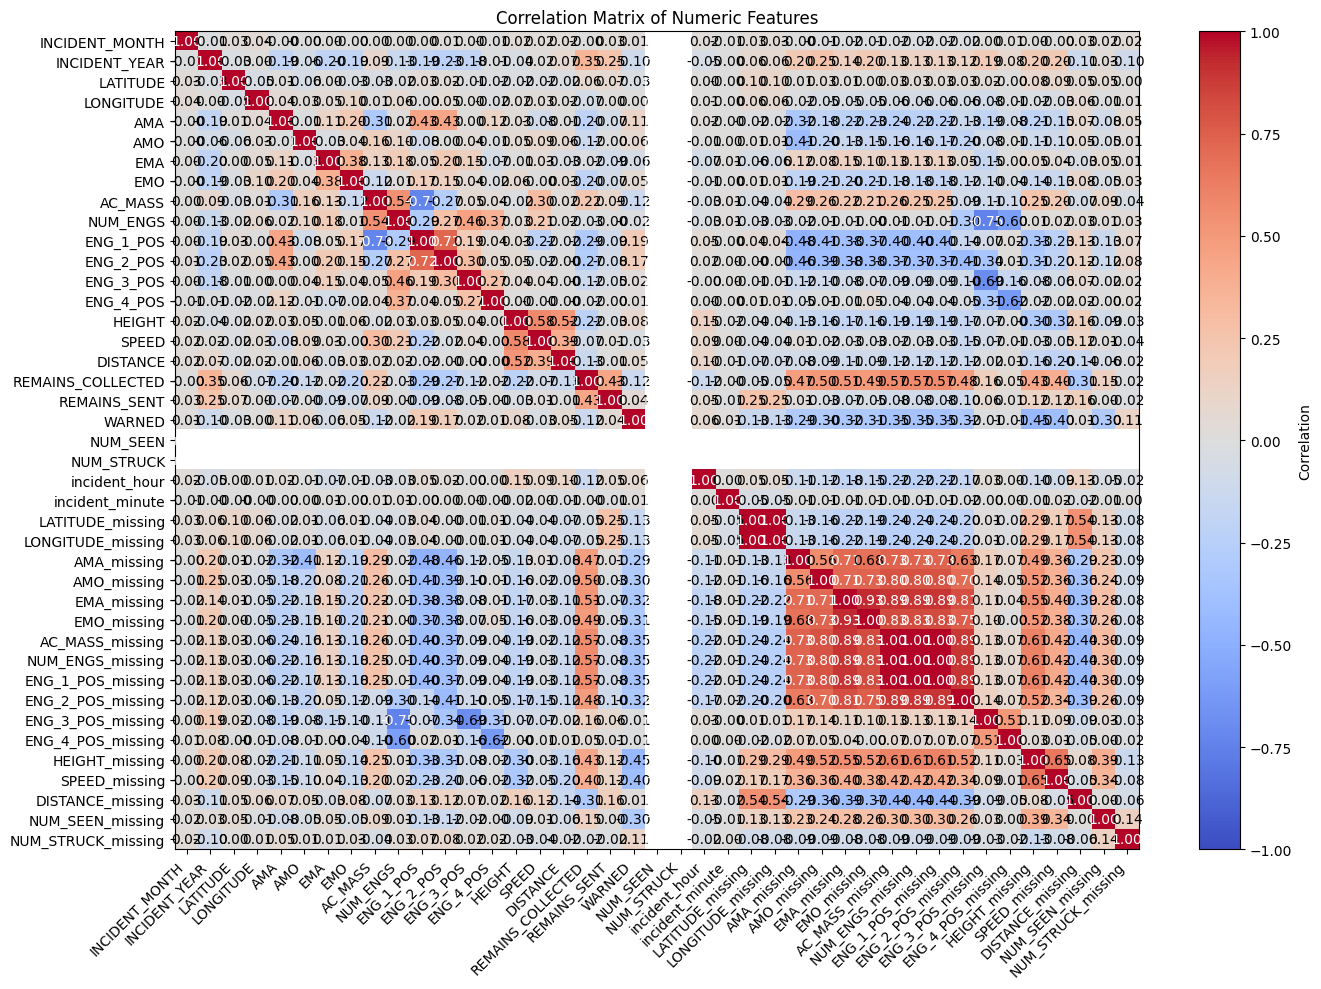

Highly correlated feature pairs (|corr| > 0.7):
               Feature1           Feature2  Correlation
1009   LATITUDE_missing  LONGITUDE_missing     0.999929
1303   NUM_ENGS_missing  ENG_1_POS_missing     0.999314
1261    AC_MASS_missing   NUM_ENGS_missing     0.996783
1262    AC_MASS_missing  ENG_1_POS_missing     0.996752
1177        EMA_missing        EMO_missing     0.925836
1345  ENG_1_POS_missing  ENG_2_POS_missing     0.893322
1304   NUM_ENGS_missing  ENG_2_POS_missing     0.892828
1180        EMA_missing  ENG_1_POS_missing     0.891941
1179        EMA_missing   NUM_ENGS_missing     0.891860
1178        EMA_missing    AC_MASS_missing     0.890910
1263    AC_MASS_missing  ENG_2_POS_missing     0.890504
1221        EMO_missing  ENG_1_POS_missing     0.826072
1220        EMO_missing   NUM_ENGS_missing     0.825985
1219        EMO_missing    AC_MASS_missing     0.825059
1181        EMA_missing  ENG_2_POS_missing     0.810034
1137        AMO_missing    AC_MASS_missing     0.802253


In [26]:
# Correlation matrix for numeric features
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'INDICATED_DAMAGE']  # Exclude target for now

if numeric_cols:
    corr_matrix = train_clean[numeric_cols].corr()
    plt.figure(figsize=(14, 10))
    im = plt.imshow(corr_matrix.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(im, label='Correlation')
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
    plt.title('Correlation Matrix of Numeric Features')
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            text = plt.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', color='black' if abs(corr_matrix.values[i, j]) < 0.7 else 'white')
    plt.tight_layout()
    plt.show()

    # Print high correlations (>0.7 or <-0.7)
    high_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
    high_corr_pairs = high_corr.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > 0.7]
    if not high_corr_pairs.empty:
        print('Highly correlated feature pairs (|corr| > 0.7):')
        print(high_corr_pairs.sort_values('Correlation', ascending=False))
    else:
        print('No highly correlated numeric feature pairs found.')


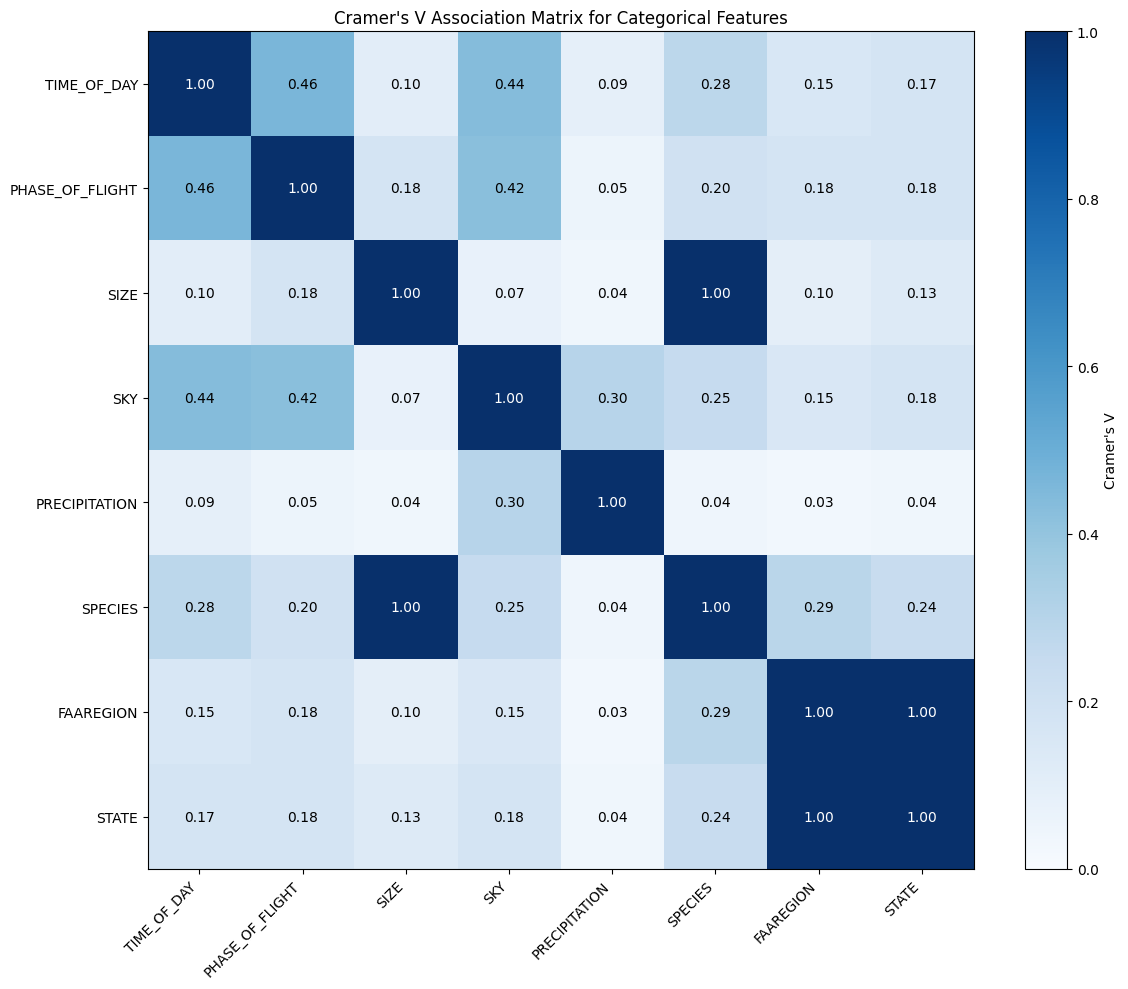

Strongly associated categorical feature pairs (Cramers V > 0.5):
     Feature1 Feature2 Cramers_V
55  FAAREGION    STATE  0.999907
21       SIZE  SPECIES  0.998487


In [30]:
# Cramer's V for categorical feature associations
import scipy.stats as stats
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES', 'FAAREGION', 'STATE']
cat_cols = [c for c in cat_cols if c in train_clean.columns]

if len(cat_cols) > 1:
    cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            if i == j:
                cramers_matrix.iloc[i, j] = 1.0
            else:
                contingency = pd.crosstab(train_clean[cat_cols[i]], train_clean[cat_cols[j]])
                cramers_matrix.iloc[i, j] = cramers_v(contingency.values)
    
    plt.figure(figsize=(12, 10))
    im = plt.imshow(cramers_matrix.values.astype(float), cmap='Blues', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label="Cramer's V")
    plt.xticks(range(len(cat_cols)), cat_cols, rotation=45, ha='right')
    plt.yticks(range(len(cat_cols)), cat_cols)
    plt.title("Cramer's V Association Matrix for Categorical Features")
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            text = plt.text(j, i, f'{cramers_matrix.values[i, j]:.2f}', ha='center', va='center', color='white' if cramers_matrix.values[i, j] > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

    # Print strong associations (>0.5)
    strong_assoc = cramers_matrix.where(np.triu(np.ones_like(cramers_matrix), k=1).astype(bool))
    strong_pairs = strong_assoc.stack().reset_index()
    strong_pairs.columns = ['Feature1', 'Feature2', 'Cramers_V']
    strong_pairs = strong_pairs[strong_pairs['Cramers_V'] > 0.5]
    if not strong_pairs.empty:
        print('Strongly associated categorical feature pairs (Cramers V > 0.5):')
        print(strong_pairs.sort_values('Cramers_V', ascending=False))
    else:
        print('No strongly associated categorical feature pairs found.')


Point-biserial correlations with INDICATED_DAMAGE:
AC_MASS: r=-0.228, p=0.000
ENG_1_POS: r=0.177, p=0.000
NUM_SEEN: r=nan, p=nan
NUM_STRUCK: r=nan, p=nan
incident_hour: r=nan, p=nan
incident_minute: r=nan, p=nan
AC_MASS_missing: r=-0.159, p=0.000
ENG_1_POS_missing: r=-0.156, p=0.000
NUM_ENGS_missing: r=-0.156, p=0.000
AMO_missing: r=-0.155, p=0.000
AMA_missing: r=-0.149, p=0.000
EMA_missing: r=-0.146, p=0.000
EMO_missing: r=-0.140, p=0.000
SPEED_missing: r=-0.139, p=0.000
INCIDENT_YEAR: r=-0.139, p=0.000
HEIGHT_missing: r=-0.133, p=0.000
REMAINS_COLLECTED: r=-0.118, p=0.000
HEIGHT: r=0.111, p=0.000
DISTANCE_missing: r=0.108, p=0.000
AMA: r=0.100, p=0.000
NUM_ENGS: r=-0.081, p=0.000
NUM_STRUCK_missing: r=0.077, p=0.000
EMO: r=0.076, p=0.000
ENG_2_POS: r=0.071, p=0.000
ENG_2_POS_missing: r=-0.070, p=0.000
WARNED: r=0.066, p=0.000
LATITUDE_missing: r=0.057, p=0.000
LONGITUDE_missing: r=0.057, p=0.000
DISTANCE: r=0.049, p=0.000
NUM_SEEN_missing: r=-0.041, p=0.000
ENG_4_POS_missing: r=-0.03

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


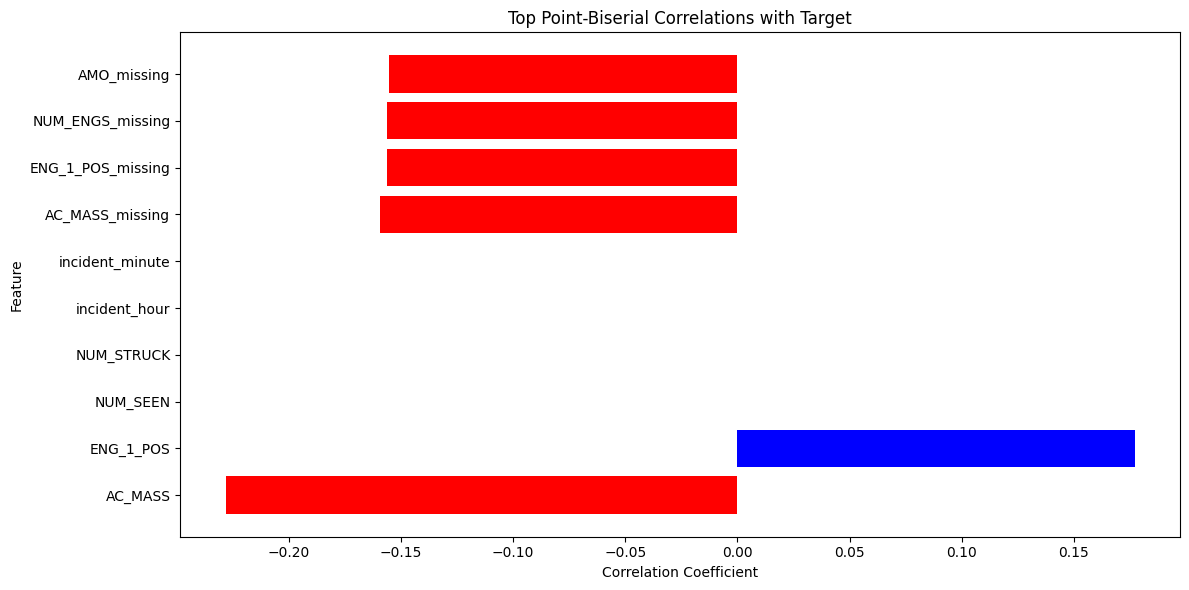

In [28]:
# Point-biserial correlation with target
from scipy.stats import pointbiserialr

if 'INDICATED_DAMAGE' in train_clean.columns:
    target = train_clean['INDICATED_DAMAGE'].astype(int)
    correlations_with_target = {}
    
    # Numeric features
    for col in numeric_cols:
        corr, p = pointbiserialr(target, train_clean[col])
        correlations_with_target[col] = {'correlation': corr, 'p_value': p}
    
    # Binary/categorical features (encode as numeric)
    binary_cols = ['REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED']
    for col in binary_cols:
        if col in train_clean.columns:
            encoded = train_clean[col].astype(int)
            corr, p = pointbiserialr(target, encoded)
            correlations_with_target[col] = {'correlation': corr, 'p_value': p}
    
    # Print results
    print('Point-biserial correlations with INDICATED_DAMAGE:')
    for feat, stats in sorted(correlations_with_target.items(), key=lambda x: abs(x[1]['correlation']), reverse=True):
        print(f'{feat}: r={stats["correlation"]:.3f}, p={stats["p_value"]:.3f}')
    
    # Visualize top correlations
    top_features = sorted(correlations_with_target.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)[:10]
    features, corrs = zip(*[(f, s['correlation']) for f, s in top_features])
    
    plt.figure(figsize=(12, 6))
    plt.barh(features, corrs, color=['red' if c < 0 else 'blue' for c in corrs])
    plt.title('Top Point-Biserial Correlations with Target')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# Feature Engineering Insights

Based on the relationship analysis:

- **High correlations**: Check the printed lists for numeric pairs with |corr| > 0.7 that might be redundant.
- **Strong associations**: Categorical features with Cramer's V > 0.5 may share information.
- **Target correlations**: Features with low |r| or high p-values might be weak predictors and candidates for removal.
- **Next steps**: Consider PCA for highly correlated numerics, grouping rare categories, or creating interaction features from strongly associated pairs.

This analysis helps prioritize features for modeling and identify potential drops or transformations.